# 12-vtrain — TCN Trading-Parameter Grid Search with Purged K-Fold Cross-Validation

## Methodology

The original `12_tcn_grid_search.ipynb` optimised trading thresholds on the **test set**, which constitutes a data leak:
the best parameters were selected by observing future (test) data, inflating reported performance.

This notebook replaces that approach with **Purged K-Fold Cross-Validation** to produce honest
Out-Of-Sample (OOS) probabilities entirely from the training data:

1. Split `train_df` into **K=5 chronological folds**
2. For each fold k: train a fresh TCN on all training data **excluding fold k plus a 168-bar embargo**
   (prevents any look-ahead from the label horizon leaking across the fold boundary)
3. Predict on fold k rows → store `P(up)` and `P(down)` as OOS probabilities
4. After all 5 folds: stack OOS probs → run grid search on these OOS probs
5. **Final honest evaluation**: load the production model (`tcn_model.pt`), apply best params to
   the test set **once only**

## Design decisions

| Choice | Value | Rationale |
|---|---|---|
| K (folds) | 5 | ~11,500 train rows per OOS fold |
| Embargo | 168 bars | 1 week in hourly bars — covers TBM vertical horizon (12h) + buffer |
| Training sequences | contiguous segments only | embargo gap must not be bridged by a single sequence |
| Fold prediction lookback | up to SEQ_LEN-1 rows before fold start | pre-computed features, no label leakage |
| QT fitting | once on full `train_df` | pragmatic — avoids recomputing 5× without materially changing signal |
| Fold epochs | 60 (vs 100 production) | keep runtime to ~30-90 min on M4 MPS |
| Fold patience | 10 (vs 15 production) | proportional to reduced epoch budget |

**Estimated runtime: ~30-90 min on M4 MacBook Pro (MPS).**

In [1]:
# ── Purged K-Fold config ──────────────────────────────────────────────────────
K         = 5
EMBARGO   = 168    # bars (1 week @ 1h)

EPOCHS_FOLD   = 60    # vs 100 in production model
PATIENCE_FOLD = 10    # vs 15 in production model

# ── Grid ─────────────────────────────────────────────────────────────────────
GRID = {
    'long_threshold':  [0.44, 0.47, 0.50, 0.53, 0.56],
    'short_threshold': [0.44, 0.47, 0.50, 0.53, 0.56],
    'atr_multiplier':  [1.5, 2.0, 2.5, 3.0],
    'min_sl':          [0.010, 0.015, 0.020],
    'take_profit':     [0.025, 0.035, 0.045],
    'min_hold':        [4, 6, 8],
    'max_hold':        [24, 48],
    'cooldown':        [2, 3],
}

MIN_TRADES      = 20
OPTIMISE_METRIC = 'sharpe'   # 'sharpe' | 'calmar' | 'total_return' | 'win_rate' | 'profit_factor'

# ── Notebook 11 settings (must match exactly) ─────────────────────────────────
SYMBOL   = 'BTCUSDT'
INTERVAL = '1h'
TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'

FRAC_D        = 0.4
FFD_THRES     = 1e-4

TBM_VOL_WINDOW = 24
TBM_PT         = 1.0
TBM_SL         = 1.0
TBM_VERT_H     = 12
AUX_FWD_H      = 6

SEQ_LEN = 24

TCN_CHANNELS = [64, 64, 64, 64]
TCN_KERNEL   = 3
TCN_DROPOUT  = 0.40

WARMUP_EPOCHS = 5
BATCH_SIZE    = 256
LR            = 2e-3
WEIGHT_DECAY  = 1e-3
LAMBDA_VOL    = 0.5

SEED = 42

In [2]:
import itertools
import json
import math
import pickle
import random
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import QuantileTransformer
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9,  'ytick.labelsize': 9,
    'legend.fontsize': 9,  'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT = '#F7931A'; BLUE = '#2962FF'; GREY = '#9E9E9E'
RED    = '#EF5350'; GREEN = '#26A69A'; PURPLE = '#7B1FA2'

REPO_ROOT = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
FIGURES_DIR  = REPO_ROOT / 'figures'
MODELS_DIR   = REPO_ROOT / 'local_models'
if not MODELS_DIR.exists():
    MODELS_DIR = REPO_ROOT / 'models'
FIGURES_DIR.mkdir(exist_ok=True)
print(f'REPO_ROOT:  {REPO_ROOT}')
print(f'MODELS_DIR: {MODELS_DIR}')

Device: mps
REPO_ROOT:  /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
MODELS_DIR: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models


In [3]:
# ── Load features ─────────────────────────────────────────────────────────────
feat_df = pd.read_parquet(FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet')
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

with open(FEATURES_DIR / 'feature_registry.json') as f:
    BACKTEST_COLS = json.load(f)['backtest_only_cols']

selected_features = pd.read_csv(MODELS_DIR / 'lgbm_features.csv', header=None)[0].tolist()
missing = [f for f in selected_features if f not in feat_df.columns]
if missing:
    raise ValueError(f'Features missing from parquet: {missing}')

# ── FFD functions ─────────────────────────────────────────────────────────────
def _ffd_weights(d, thres=1e-4):
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] / k * (d - k + 1)
        if abs(w_k) < thres: break
        w.append(w_k); k += 1
    return np.array(w[::-1])

def frac_diff_ffd(series, d, thres=1e-4):
    weights = _ffd_weights(d, thres)
    width   = len(weights)
    vals    = series.values.astype(np.float64)
    out     = np.full(len(vals), np.nan)
    for i in range(width - 1, len(vals)):
        out[i] = np.dot(weights, vals[i - width + 1 : i + 1])
    return pd.Series(out, index=series.index)

# ── FracDiff close ────────────────────────────────────────────────────────────
log_close      = np.log(feat_df['close'])
fracdiff_close = frac_diff_ffd(log_close, FRAC_D, FFD_THRES)
feat_df['fracdiff_close'] = fracdiff_close

# ── TBM labels ───────────────────────────────────────────────────────────────
log_rets    = log_close.diff()
rolling_vol = log_rets.rolling(TBM_VOL_WINDOW).std()
close_vals  = feat_df['close'].values
vol_vals    = rolling_vol.values
n           = len(close_vals)
tbm_labels  = np.full(n, np.nan)

for i in range(n - TBM_VERT_H):
    if np.isnan(vol_vals[i]) or vol_vals[i] <= 0: continue
    entry = close_vals[i]
    upper = entry * (1 + TBM_PT * vol_vals[i])
    lower = entry * (1 - TBM_SL * vol_vals[i])
    lbl   = 2
    for j in range(1, TBM_VERT_H + 1):
        px = close_vals[i + j]
        if px >= upper: lbl = 1; break
        elif px <= lower: lbl = 0; break
    tbm_labels[i] = lbl
feat_df['tbm_label'] = tbm_labels

# ── Aux vol + sample weights ──────────────────────────────────────────────────
fwd_vol = pd.concat([log_rets.shift(-h) for h in range(1, AUX_FWD_H + 1)], axis=1).std(axis=1)
feat_df['fwd_vol'] = fwd_vol
w_raw = rolling_vol.fillna(rolling_vol.median()) / rolling_vol.median()
feat_df['sample_weight'] = w_raw.clip(0.3, 3.0).fillna(1.0)

# ── Build clean_df & split ────────────────────────────────────────────────────
ALL_INPUT_FEATS = selected_features + ['fracdiff_close']
required_cols   = ALL_INPUT_FEATS + ['tbm_label', 'fwd_vol', 'sample_weight'] + BACKTEST_COLS
clean_df        = feat_df[required_cols].dropna()

train_df, val_df, test_df = calendar_split(clean_df, train_end=TRAIN_END, val_end=VAL_END)
# Reset to integer positional index for K-fold slicing
clean_train = train_df.reset_index(drop=False)   # keep original datetime as column
clean_val   = val_df
clean_test  = test_df

print(f'Loaded {len(feat_df):,} total rows')
print(f'After NaN drop: {len(clean_df):,} rows')
print(f'Train: {len(train_df):>7,}  {train_df.index.min().date()} → {train_df.index.max().date()}')
print(f'Val:   {len(val_df):>7,}  {val_df.index.min().date()} → {val_df.index.max().date()}')
print(f'Test:  {len(test_df):>7,}  {test_df.index.min().date()} → {test_df.index.max().date()}')
print(f'Input features: {len(ALL_INPUT_FEATS)}')

Loaded 74,366 total rows
After NaN drop: 74,073 rows
Train:  56,949  2017-11-27 → 2024-06-01
Val:     3,888  2024-06-01 → 2024-11-10
Test:   13,236  2024-11-10 → 2026-05-15
Input features: 51


In [4]:
# ── TCN model definition (identical to notebook 11 / saved tcn_model.pt) ─────
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation):
        super().__init__()
        self.pad  = (kernel - 1) * dilation
        self.conv = nn.utils.weight_norm(
            nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=self.pad))
    def forward(self, x):
        out = self.conv(x)
        return out[:, :, :-self.pad] if self.pad > 0 else out

class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(in_ch, out_ch, kernel, dilation), nn.ReLU(True), nn.Dropout(dropout),
            CausalConv1d(out_ch, out_ch, kernel, dilation), nn.ReLU(True), nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
    def forward(self, x):
        res = self.downsample(x) if self.downsample is not None else x
        return F.relu(self.net(x) + res)

class TCNMultiTask(nn.Module):
    def __init__(self, input_dim, channels, kernel, dropout):
        super().__init__()
        blocks, in_ch = [], input_dim
        for i, ch in enumerate(channels):
            blocks.append(TCNBlock(in_ch, ch, kernel, 2**i, dropout)); in_ch = ch
        self.tcn = nn.Sequential(*blocks)
        d = channels[-1]
        self.head_dir = nn.Sequential(
            nn.LayerNorm(d), nn.Linear(d, 32), nn.GELU(),
            nn.Dropout(dropout * .5), nn.Linear(32, 3))
        self.head_vol = nn.Sequential(
            nn.LayerNorm(d), nn.Linear(d, 16), nn.GELU(),
            nn.Linear(16, 1), nn.Softplus())
    def forward(self, x):
        out  = self.tcn(x.transpose(1, 2))
        last = out[:, :, -1]
        return self.head_dir(last), self.head_vol(last).squeeze(-1)

n_params = sum(p.numel() for p in TCNMultiTask(
    len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).parameters())
print(f'TCNMultiTask: {n_params:,} parameters')

# ── LR lambda factory (fold-aware) ────────────────────────────────────────────
def make_lr_lambda(total_epochs, warmup):
    def lr_lambda(epoch):
        if epoch < warmup:
            return (epoch + 1) / warmup
        progress = (epoch - warmup) / max(1, total_epochs - warmup)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return lr_lambda

TCNMultiTask: 103,652 parameters


In [5]:
# ── Fit QuantileTransformer ONCE on all training data ─────────────────────────
# Pragmatic approximation: avoids 5× refitting while keeping the QT consistent
# with the production model's normalisation scale.
qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
qt.fit(train_df[ALL_INPUT_FEATS].values)
print(f'QuantileTransformer fitted on train_df: {train_df[ALL_INPUT_FEATS].shape}')

# Pre-transform the entire train matrix for efficiency inside the fold loop
X_train_qt = qt.transform(train_df[ALL_INPUT_FEATS].values).astype(np.float32)
y_train_all = train_df['tbm_label'].values.astype(np.int64)
w_train_all = train_df['sample_weight'].values.astype(np.float32)
v_train_all = train_df['fwd_vol'].values.astype(np.float32)

# Val arrays (used for early stopping in every fold)
X_val_qt   = qt.transform(clean_val[ALL_INPUT_FEATS].values).astype(np.float32)
y_val_all  = clean_val['tbm_label'].values.astype(np.int64)
v_val_all  = clean_val['fwd_vol'].values.astype(np.float32)

# Build val sequences
X_vl = torch.tensor(
    np.array([X_val_qt[i - SEQ_LEN:i] for i in range(SEQ_LEN, len(X_val_qt))],
             dtype=np.float32))
y_vl = torch.tensor(y_val_all[SEQ_LEN:].astype(np.int64))
v_vl = torch.tensor(v_val_all[SEQ_LEN:].astype(np.float32))
print(f'Val sequences: {X_vl.shape}  y_vl: {y_vl.shape}')

QuantileTransformer fitted on train_df: (56949, 51)
Val sequences: torch.Size([3864, 24, 51])  y_vl: torch.Size([3864])


## 1. Purged K-Fold OOS probability generation

For each fold k covering rows `[fold_start, fold_end)` in `train_df`:
- **Embargo zone**: rows `[fold_start - EMBARGO, fold_end + EMBARGO)` are excluded from training
- **Training sequences**: only built from contiguous segments (no single sequence may bridge the embargo gap)
- **Fold prediction**: the model predicts on fold rows using up to `SEQ_LEN-1` pre-fold lookback
  (pre-computed features only — no label leakage)

After 5 folds every training row (except the first `SEQ_LEN-1` rows of fold 0) has an OOS prediction.

In [6]:
N_TRAIN = len(train_df)

# Storage for OOS probabilities aligned to train_df row positions
oos_up   = np.full(N_TRAIN, np.nan, dtype=np.float32)
oos_down = np.full(N_TRAIN, np.nan, dtype=np.float32)

# Track which train rows got OOS predictions (for backtest alignment later)
oos_indices = []   # list of arrays, one per fold

fold_size = N_TRAIN // K

print(f'K={K} folds × ~{EPOCHS_FOLD} epochs × ~{N_TRAIN:,} train sequences ≈ 30-90 min on M4 MPS')
print(f'Fold size: ~{fold_size:,} rows  |  Embargo: {EMBARGO} bars each side\n')

for k in range(K):
    print(f'{'='*60}')
    fold_start = k * fold_size
    fold_end   = (k + 1) * fold_size if k < K - 1 else N_TRAIN

    emb_start = max(0,       fold_start - EMBARGO)
    emb_end   = min(N_TRAIN, fold_end   + EMBARGO)

    print(f'Fold {k+1}/{K}: rows [{fold_start}, {fold_end})  '
          f'embargo [{emb_start}, {emb_end})')

    # ── Build training mask: exclude fold + embargo ──────────────────────────
    train_mask = np.ones(N_TRAIN, dtype=bool)
    train_mask[emb_start:emb_end] = False
    train_indices = np.where(train_mask)[0]

    # ── Find contiguous segments within training indices ─────────────────────
    # A gap > 1 in positional indices means the embargo interrupted continuity
    if len(train_indices) > 1:
        gaps = np.where(np.diff(train_indices) > 1)[0]
        seg_boundaries = np.concatenate([[0], gaps + 1, [len(train_indices)]])
    else:
        seg_boundaries = np.array([0, len(train_indices)])

    # ── Build training sequences from contiguous segments only ────────────────
    X_fold_seqs, y_fold_seqs, w_fold_seqs, v_fold_seqs = [], [], [], []

    for s_start, s_end in zip(seg_boundaries[:-1], seg_boundaries[1:]):
        seg_idx = train_indices[s_start:s_end]
        seg_len = len(seg_idx)
        if seg_len < SEQ_LEN:
            continue
        for i in range(SEQ_LEN - 1, seg_len):
            window = seg_idx[i - SEQ_LEN + 1 : i + 1]
            X_fold_seqs.append(X_train_qt[window])
            y_fold_seqs.append(y_train_all[seg_idx[i]])
            w_fold_seqs.append(w_train_all[seg_idx[i]])
            v_fold_seqs.append(v_train_all[seg_idx[i]])

    X_tr = torch.tensor(np.array(X_fold_seqs, dtype=np.float32))
    y_tr = torch.tensor(np.array(y_fold_seqs, dtype=np.int64))
    w_tr = torch.tensor(np.array(w_fold_seqs, dtype=np.float32))
    v_tr = torch.tensor(np.array(v_fold_seqs, dtype=np.float32))
    print(f'  Train seqs: {len(X_tr):,}  from {len(seg_boundaries)-1} segments')

    # ── Class weights from this fold's training labels ────────────────────────
    class_counts = np.bincount(y_tr.numpy(), minlength=3).astype(np.float32)
    class_weights = torch.tensor(
        class_counts.sum() / (3 * class_counts + 1e-8),
        dtype=torch.float32
    ).to(DEVICE)

    # ── Instantiate model & optimiser ────────────────────────────────────────
    model = TCNMultiTask(len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=make_lr_lambda(EPOCHS_FOLD, WARMUP_EPOCHS)
    )

    dataset_tr = TensorDataset(X_tr, y_tr, w_tr, v_tr)
    loader_tr  = DataLoader(dataset_tr, batch_size=BATCH_SIZE, shuffle=True,
                            drop_last=True, num_workers=0)
    dataset_vl = TensorDataset(X_vl, y_vl, torch.ones(len(y_vl)), v_vl)
    loader_vl  = DataLoader(dataset_vl, batch_size=512, shuffle=False, num_workers=0)

    # ── Training loop ────────────────────────────────────────────────────────
    best_val_loss = np.inf
    patience_count = 0
    best_state = None

    for epoch in range(EPOCHS_FOLD):
        model.train()
        for xb, yb, wb, vb in loader_tr:
            xb, yb, wb, vb = xb.to(DEVICE), yb.to(DEVICE), wb.to(DEVICE), vb.to(DEVICE)
            optimizer.zero_grad()
            logits, vol_pred = model(xb)
            ce_per   = F.cross_entropy(logits, yb, weight=class_weights, reduction='none')
            loss_dir = (ce_per * wb).mean()
            hub_per  = F.huber_loss(vol_pred, vb, reduction='none')
            loss_vol = (hub_per * wb).mean()
            loss = loss_dir + LAMBDA_VOL * loss_vol
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        # Validate
        model.eval()
        val_loss_acc = 0.0
        with torch.no_grad():
            for xb, yb, _, vb in loader_vl:
                xb, yb, vb = xb.to(DEVICE), yb.to(DEVICE), vb.to(DEVICE)
                logits, vol_pred = model(xb)
                ce  = F.cross_entropy(logits, yb, reduction='mean')
                hub = F.huber_loss(vol_pred, vb, reduction='mean')
                val_loss_acc += (ce + LAMBDA_VOL * hub).item() * len(xb)
        val_loss = val_loss_acc / len(loader_vl.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {kk: vv.cpu().clone() for kk, vv in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= PATIENCE_FOLD:
            print(f'  Early stop at epoch {epoch+1}  (best val loss: {best_val_loss:.5f})')
            break

        if (epoch + 1) % 10 == 0:
            print(f'  Ep {epoch+1:>3}/{EPOCHS_FOLD}  val_loss={val_loss:.5f}  '
                  f'best={best_val_loss:.5f}  patience={patience_count}')

    model.load_state_dict(best_state)

    # ── Predict on fold rows with SEQ_LEN lookback ────────────────────────────
    # Use up to SEQ_LEN-1 rows before fold_start as lookback context.
    # These are pre-computed features (no label leakage).
    lookback_start = max(0, fold_start - (SEQ_LEN - 1))
    X_fold_context = X_train_qt[lookback_start:fold_end]  # lookback + fold rows
    offset         = fold_start - lookback_start           # prepended lookback rows

    X_fold_pred_seqs = []
    fold_pred_positions = []  # absolute positions in train_df

    for i in range(offset, len(X_fold_context)):
        if i >= SEQ_LEN:
            X_fold_pred_seqs.append(X_fold_context[i - SEQ_LEN:i])
            fold_pred_positions.append(lookback_start + i)  # absolute index in train_df

    if len(X_fold_pred_seqs) == 0:
        print(f'  WARNING: fold {k+1} produced no prediction sequences (fold too small)')
        model.cpu()
        del model
        if DEVICE.type == 'mps': torch.mps.empty_cache()
        continue

    X_fold_pred_seqs = np.array(X_fold_pred_seqs, dtype=np.float32)
    fold_pred_positions = np.array(fold_pred_positions, dtype=np.int64)

    # Run inference in batches
    model.eval()
    logits_list = []
    with torch.no_grad():
        for xb, in DataLoader(
            TensorDataset(torch.from_numpy(X_fold_pred_seqs)),
            batch_size=512
        ):
            lgts, _ = model(xb.to(DEVICE))
            logits_list.append(lgts.cpu())

    logits_fold = torch.cat(logits_list).numpy()
    probs_fold  = torch.softmax(torch.tensor(logits_fold), dim=1).numpy()

    # Store OOS probabilities at the correct positions in train_df
    for pos, p_down, p_up in zip(fold_pred_positions, probs_fold[:, 0], probs_fold[:, 1]):
        oos_down[pos] = p_down
        oos_up[pos]   = p_up

    oos_indices.append(fold_pred_positions)

    # Free model from MPS/GPU to release memory
    model.cpu()
    del model
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()
    elif DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    print(f'  Fold {k+1}/{K} done: {len(probs_fold):,} OOS predictions stored')

print(f'\nAll folds complete.')
valid_mask = ~np.isnan(oos_up)
print(f'OOS coverage: {valid_mask.sum():,} / {N_TRAIN:,} train rows ({valid_mask.mean()*100:.1f}%)')

K=5 folds × ~60 epochs × ~56,949 train sequences ≈ 30-90 min on M4 MPS
Fold size: ~11,389 rows  |  Embargo: 168 bars each side

Fold 1/5: rows [0, 11389)  embargo [0, 11557)
  Train seqs: 45,369  from 1 segments
  Ep  10/60  val_loss=1.02685  best=0.97225  patience=9
  Early stop at epoch 11  (best val loss: 0.97225)
  Fold 1/5 done: 11,365 OOS predictions stored
Fold 2/5: rows [11389, 22778)  embargo [11221, 22946)
  Train seqs: 45,178  from 2 segments
  Ep  10/60  val_loss=1.23028  best=0.96649  patience=9
  Early stop at epoch 11  (best val loss: 0.96649)
  Fold 2/5 done: 11,388 OOS predictions stored
Fold 3/5: rows [22778, 34167)  embargo [22610, 34335)
  Train seqs: 45,178  from 2 segments
  Ep  10/60  val_loss=1.04468  best=0.96207  patience=8
  Early stop at epoch 12  (best val loss: 0.96207)
  Fold 3/5 done: 11,388 OOS predictions stored
Fold 4/5: rows [34167, 45556)  embargo [33999, 45724)
  Train seqs: 45,178  from 2 segments
  Ep  10/60  val_loss=1.02499  best=0.97506  patie

OOS rows for grid search: 56,921
Date range: 2017-11-28 → 2024-06-01
P(up)   — mean=0.3751  std=0.1081  range=[0.0556, 0.6045]
P(down) — mean=0.3536  std=0.0906  range=[0.0616, 0.5357]


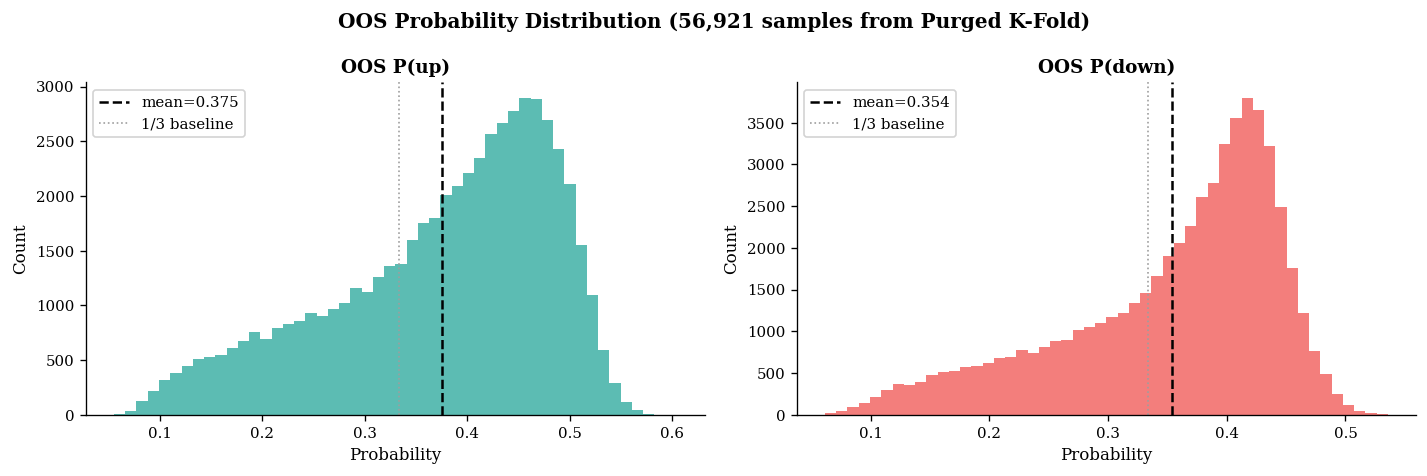

In [7]:
# ── OOS probability stats ─────────────────────────────────────────────────────
valid_mask = ~np.isnan(oos_up)
oos_up_valid   = oos_up[valid_mask]
oos_down_valid = oos_down[valid_mask]

# Align train_df arrays for backtest
oos_close = train_df['close'].values[valid_mask].astype(np.float64)
oos_atr   = train_df['atr_14_pct'].values[valid_mask].astype(np.float64)
oos_index = train_df.index[valid_mask]

# Buy-and-hold baseline on OOS period
bh_equity_oos = oos_close / oos_close[0]

print(f'OOS rows for grid search: {len(oos_up_valid):,}')
print(f'Date range: {oos_index.min().date()} → {oos_index.max().date()}')
print(f'P(up)   — mean={oos_up_valid.mean():.4f}  std={oos_up_valid.std():.4f}  '
      f'range=[{oos_up_valid.min():.4f}, {oos_up_valid.max():.4f}]')
print(f'P(down) — mean={oos_down_valid.mean():.4f}  std={oos_down_valid.std():.4f}  '
      f'range=[{oos_down_valid.min():.4f}, {oos_down_valid.max():.4f}]')

# Plot OOS prob distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, prob, label, color in [
    (axes[0], oos_up_valid,   'OOS P(up)',   GREEN),
    (axes[1], oos_down_valid, 'OOS P(down)', RED),
]:
    ax.hist(prob, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(prob.mean(), color='black', ls='--', lw=1.5,
               label=f'mean={prob.mean():.3f}')
    ax.axvline(1/3, color=GREY, ls=':', lw=1, label='1/3 baseline')
    ax.set_xlabel('Probability'); ax.set_ylabel('Count')
    ax.set_title(label, fontweight='bold')
    ax.legend()
fig.suptitle(f'OOS Probability Distribution ({len(oos_up_valid):,} samples from Purged K-Fold)',
             fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'tcn_oos_prob_distribution_vtrain.png')
plt.show()

## 2. Grid search on OOS probabilities

The backtest function is evaluated on the OOS training-set probabilities — **no test data is touched here**.

- Long signal: `P(up) >= long_threshold`
- Short signal: `P(down) >= short_threshold AND P(up) < long_threshold`
- Exit: ATR stop-loss → take-profit → max hold → confidence exit (after min hold)

In [8]:
# ── Backtest function (OOS) ───────────────────────────────────────────────────
# Uses module-level oos_up_valid, oos_down_valid, oos_close, oos_atr, bh_equity_oos

def run_backtest(p: dict) -> dict | None:
    """Run one backtest on OOS probs with parameter dict `p`.
    Returns metrics dict or None if fewer than MIN_TRADES trades."""
    lt  = p['long_threshold'];  st  = p['short_threshold']
    elt = max(0.28, lt - 0.10); est = max(0.28, st - 0.10)
    atr = p['atr_multiplier'];  msl = p['min_sl']
    tp  = p['take_profit']
    mnh = p['min_hold'];        mxh = p['max_hold']
    cd  = p['cooldown']

    cash = 1.0; units = 0.0
    in_pos = False; direction = None
    entry_px = 0.0; entry_cash = 0.0; dynamic_sl = 0.0
    hold_count = 0; cooldown = 0

    equity = np.empty(len(oos_close), dtype=np.float64)
    n_long = n_short = n_sl = n_tp = n_conf = 0
    wins   = 0; total_pnl = 0.0

    for i in range(len(oos_close)):
        px   = oos_close[i]
        p_up = oos_up_valid[i]
        p_dn = oos_down_valid[i]

        if cooldown > 0: cooldown -= 1

        if in_pos:
            hold_count += 1
            pnl    = (px - entry_px) / entry_px if direction == 'long' \
                     else (entry_px - px) / entry_px
            reason = None
            if   pnl <= -dynamic_sl:                                         reason = 'sl'
            elif pnl >= tp:                                                   reason = 'tp'
            elif hold_count >= mxh:                                           reason = 'max_hold'
            elif hold_count >= mnh:
                if   direction == 'long'  and p_up < elt:                    reason = 'conf'
                elif direction == 'short' and p_dn < est:                    reason = 'conf'

            if reason:
                cash  = units * px if direction == 'long' else entry_cash * (1 + pnl)
                units = 0.0
                if reason == 'sl':   n_sl   += 1
                elif reason == 'tp': n_tp   += 1
                else:                n_conf += 1
                wins += int(pnl > 0); total_pnl += pnl
                in_pos = False; hold_count = 0; cooldown = cd

        if not in_pos and cooldown == 0:
            sl = max(atr * oos_atr[i], msl)
            if p_up >= lt:
                units = cash / px; cash = 0.0; in_pos = True; direction = 'long'
                entry_px = px; entry_cash = 0.0; hold_count = 0; dynamic_sl = sl
                n_long += 1
            elif p_dn >= st and p_up < lt:
                entry_cash = cash; units = cash / px
                in_pos = True; direction = 'short'
                entry_px = px; hold_count = 0; dynamic_sl = sl
                n_short += 1

        if in_pos and direction == 'long':
            equity[i] = units * px
        elif in_pos and direction == 'short':
            equity[i] = entry_cash * (1 + (entry_px - px) / entry_px)
        else:
            equity[i] = cash

    # Force-close at end
    if in_pos:
        px  = oos_close[-1]
        pnl = (px - entry_px)/entry_px if direction == 'long' else (entry_px - px)/entry_px
        cash = units * px if direction == 'long' else entry_cash * (1 + pnl)
        wins += int(pnl > 0); total_pnl += pnl
        equity[-1] = cash

    n_trades = n_long + n_short
    if n_trades < MIN_TRADES: return None

    # Metrics
    eq = equity
    r  = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    sharpe = float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(24 * 365)) if len(r) > 1 else 0.0
    pk     = np.maximum.accumulate(eq)
    dd_arr = (eq - pk) / (pk + 1e-12)
    max_dd = float(dd_arr.min())
    calmar = float((eq[-1] - 1) / (-max_dd + 1e-12)) if max_dd < 0 else 0.0
    win_rate  = wins / n_trades
    avg_pnl   = total_pnl / n_trades
    gross_win  = total_pnl / max(wins, 1)
    gross_loss = (total_pnl - wins * gross_win) / max(n_trades - wins, 1)
    profit_factor = abs(gross_win * wins / (gross_loss * (n_trades - wins) + 1e-12))

    return {
        **p,
        'n_trades': n_trades, 'n_long': n_long, 'n_short': n_short,
        'n_sl': n_sl, 'n_tp': n_tp, 'n_conf': n_conf,
        'total_return':  float(eq[-1] - 1),
        'sharpe':        sharpe,
        'max_dd':        max_dd,
        'calmar':        calmar,
        'win_rate':      win_rate,
        'avg_pnl':       avg_pnl,
        'profit_factor': profit_factor,
        'alpha':         float(eq[-1] - bh_equity_oos[-1]),
    }

print('run_backtest() defined (operates on OOS probs).')
print(f'BH return on OOS period: {(bh_equity_oos[-1]-1)*100:+.2f}%')

run_backtest() defined (operates on OOS probs).
BH return on OOS period: +603.44%


In [9]:
import time

keys   = list(GRID.keys())
combos = list(itertools.product(*[GRID[k] for k in keys]))
print(f'Total combinations: {len(combos):,}')

# Rough timing estimate
sample_p = dict(zip(keys, combos[0]))
t0 = time.perf_counter()
for _ in range(10): run_backtest(sample_p)
t_per = (time.perf_counter() - t0) / 10
print(f'~{t_per*1000:.1f} ms per backtest  →  ~{t_per*len(combos):.0f}s total  '
      f'({t_per*len(combos)/60:.1f} min)')

Total combinations: 10,800
~16.5 ms per backtest  →  ~178s total  (3.0 min)


In [10]:
results = []
for vals in tqdm(combos, desc='Grid search (OOS)', ncols=80):
    p   = dict(zip(keys, vals))
    out = run_backtest(p)
    if out is not None:
        results.append(out)

results_df = pd.DataFrame(results)
print(f'\nValid combos (>={MIN_TRADES} trades): {len(results_df):,} / {len(combos):,}')
if results_df.empty:
    print('No valid results — lower MIN_TRADES or widen the grid.')
else:
    print(f'Sharpe  range: [{results_df["sharpe"].min():.3f}, {results_df["sharpe"].max():.3f}]')
    print(f'Return  range: [{results_df["total_return"].min()*100:.1f}%, '
          f'{results_df["total_return"].max()*100:.1f}%]')
    print(f'MaxDD   range: [{results_df["max_dd"].min()*100:.1f}%, '
          f'{results_df["max_dd"].max()*100:.1f}%]')

Grid search (OOS): 100%|██████████████████| 10800/10800 [02:42<00:00, 66.34it/s]


Valid combos (>=20 trades): 10,800 / 10,800
Sharpe  range: [-0.527, 1.150]
Return  range: [-83.2%, 2094.7%]
MaxDD   range: [-90.9%, -9.3%]


In [11]:
if results_df.empty:
    print('No results to display.')
else:
    top20 = results_df.sort_values(OPTIMISE_METRIC, ascending=False).head(20)
    display_cols = [
        'long_threshold','short_threshold','atr_multiplier','min_sl','take_profit',
        'min_hold','max_hold','cooldown',
        'n_trades','win_rate','total_return','sharpe','max_dd','calmar','profit_factor','alpha',
    ]
    fmt = {
        'win_rate':       '{:.1%}',
        'total_return':   '{:+.2%}',
        'sharpe':         '{:.3f}',
        'max_dd':         '{:.2%}',
        'calmar':         '{:.3f}',
        'profit_factor':  '{:.3f}',
        'alpha':          '{:+.2%}',
    }
    from IPython.display import display
    print(f'Top 20 configurations (optimised on: {OPTIMISE_METRIC})')
    display(top20[display_cols].style.format(fmt))

Top 20 configurations (optimised on: sharpe)


,long_threshold,short_threshold,atr_multiplier,min_sl,take_profit,min_hold,max_hold,cooldown,n_trades,win_rate,total_return,sharpe,max_dd,calmar,profit_factor,alpha
8313,0.530000,0.560000,1.500000,0.020000,0.045000,8,24,3,388,60.1%,+329.79%,1.150,-37.70%,8.748,1592196632841.968,-273.65%
8241,0.530000,0.560000,1.500000,0.010000,0.045000,8,24,3,394,57.6%,+308.17%,1.136,-36.09%,8.538,1535042864938.227,-295.27%
8315,0.530000,0.560000,1.500000,0.020000,0.045000,8,48,3,383,59.5%,+320.94%,1.124,-38.06%,8.432,1576059690725.831,-282.50%
8277,0.530000,0.560000,1.500000,0.015000,0.045000,8,24,3,391,58.3%,+293.25%,1.100,-39.76%,7.376,1499328236071.973,-310.19%
8243,0.530000,0.560000,1.500000,0.010000,0.045000,8,48,3,391,57.0%,+289.79%,1.089,-38.00%,7.625,1493695167188.071,-313.65%
7881,0.530000,0.530000,1.500000,0.020000,0.045000,8,24,3,391,59.8%,+300.12%,1.087,-40.63%,7.387,1522098704893.621,-303.32%
7809,0.530000,0.530000,1.500000,0.010000,0.045000,8,24,3,397,57.4%,+283.92%,1.080,-39.10%,7.261,1475037343176.039,-319.52%
8385,0.530000,0.560000,2.000000,0.015000,0.045000,8,24,3,385,60.3%,+299.57%,1.074,-34.32%,8.730,1526572368310.581,-303.87%
8349,0.530000,0.560000,2.000000,0.010000,0.045000,8,24,3,385,60.0%,+296.92%,1.072,-33.30%,8.916,1519533080942.907,-306.52%
7116,0.530000,0.470000,2.000000,0.020000,0.045000,4,24,2,711,57.2%,+616.17%,1.070,-26.85%,22.946,2248034097374.490,+12.73%


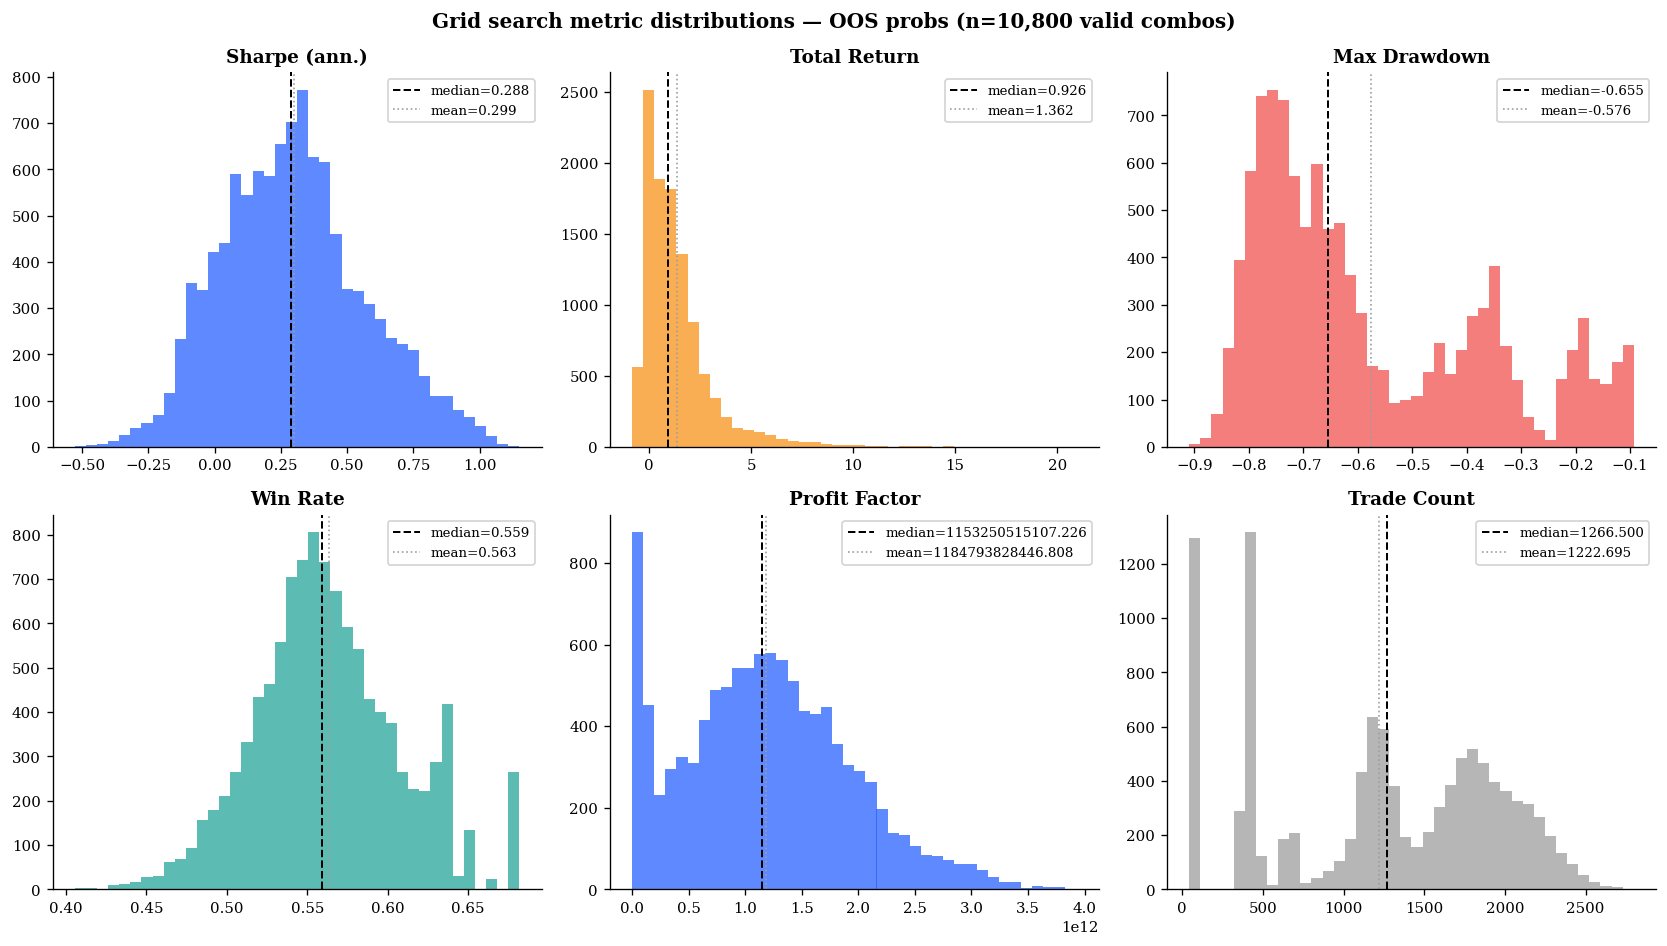

In [12]:
if not results_df.empty:
    metrics_to_plot = [
        ('sharpe',        'Sharpe (ann.)',    BLUE),
        ('total_return',  'Total Return',     ACCENT),
        ('max_dd',        'Max Drawdown',     RED),
        ('win_rate',      'Win Rate',         GREEN),
        ('profit_factor', 'Profit Factor',    BLUE),
        ('n_trades',      'Trade Count',      GREY),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, (col, label, color) in zip(axes.flat, metrics_to_plot):
        vals = results_df[col]
        ax.hist(vals, bins=40, color=color, alpha=0.75, edgecolor='none')
        ax.axvline(vals.median(), color='black', ls='--', lw=1.2,
                   label=f'median={vals.median():.3f}')
        ax.axvline(vals.mean(), color=GREY, ls=':', lw=1,
                   label=f'mean={vals.mean():.3f}')
        ax.set_title(label, fontweight='bold'); ax.legend(fontsize=8)
    fig.suptitle(
        f'Grid search metric distributions — OOS probs (n={len(results_df):,} valid combos)',
        fontweight='bold')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'tcn_grid_distributions_vtrain.png')
    plt.show()

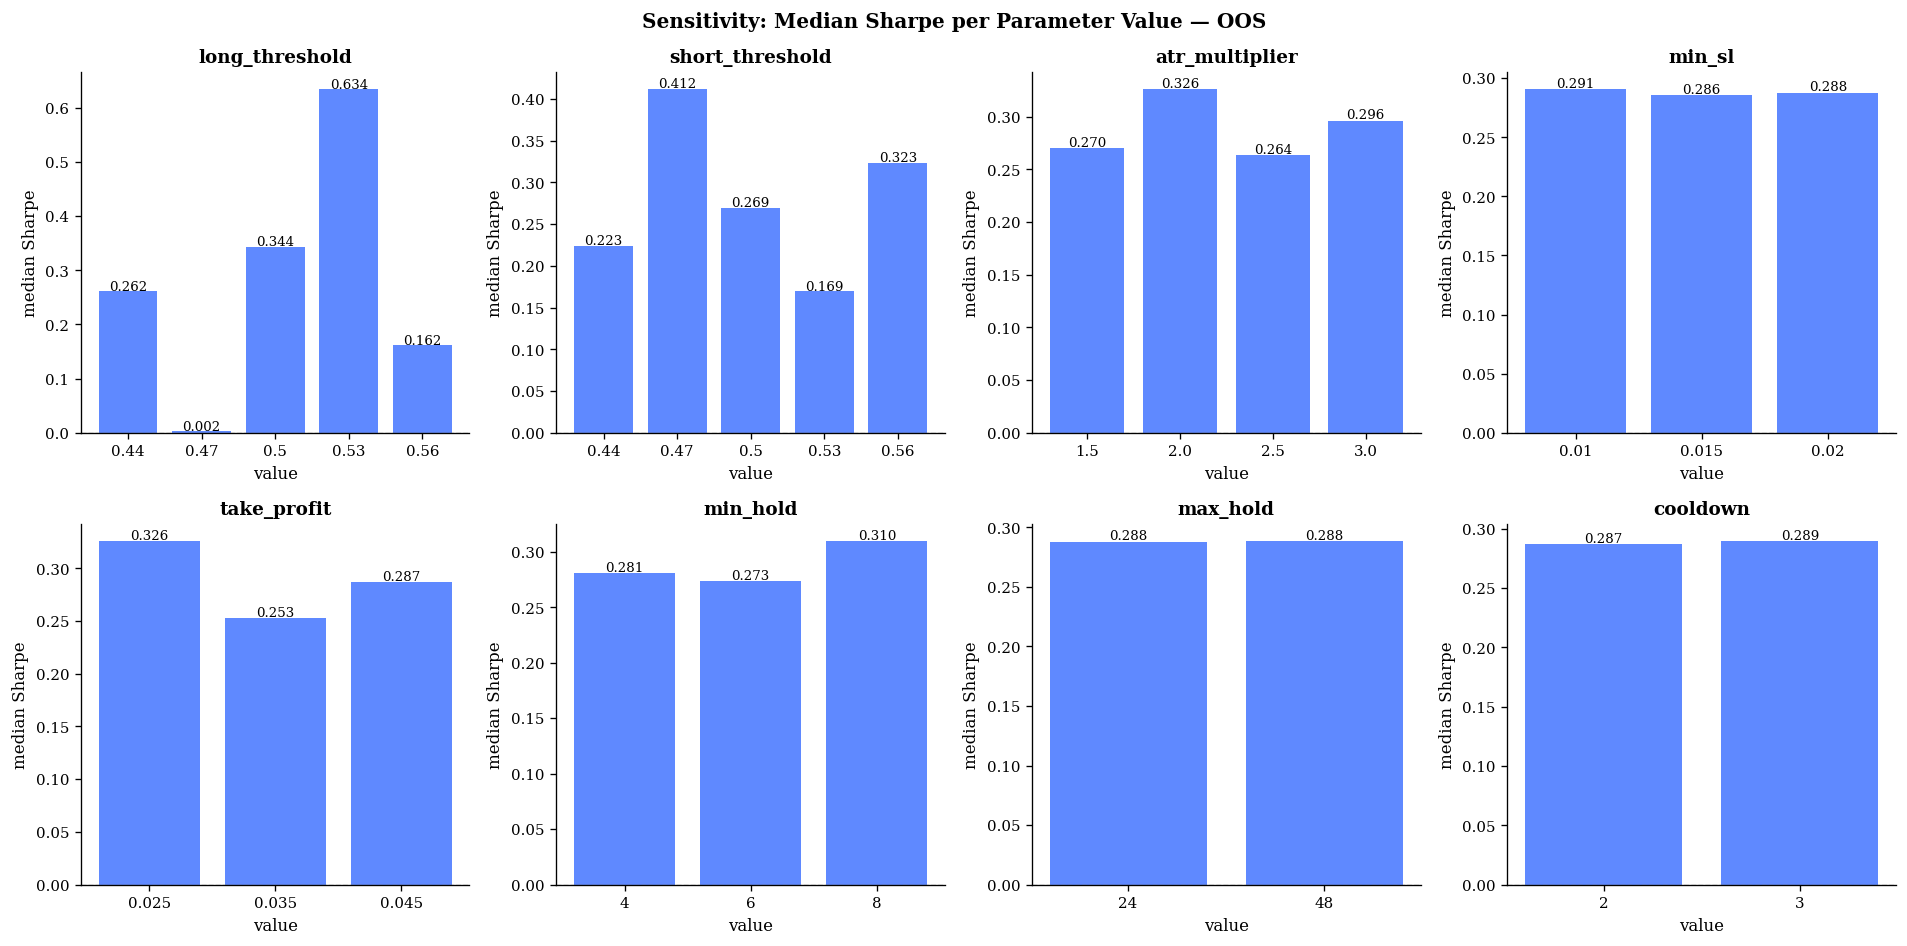

In [13]:
if not results_df.empty:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for ax, param in zip(axes.flat, keys):
        grp = results_df.groupby(param)['sharpe'].median()
        ax.bar(grp.index.astype(str), grp.values, color=BLUE, alpha=0.75)
        ax.axhline(0, color=GREY, ls='--', lw=0.8)
        ax.set_title(param, fontweight='bold')
        ax.set_xlabel('value'); ax.set_ylabel('median Sharpe')
        for i, (v, h) in enumerate(zip(grp.index.astype(str), grp.values)):
            ax.text(i, h + 0.002, f'{h:.3f}', ha='center', fontsize=8)
    fig.suptitle('Sensitivity: Median Sharpe per Parameter Value — OOS',
                 fontweight='bold')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'tcn_grid_sensitivity_vtrain.png')
    plt.show()

Best configuration (on OOS probs):
  long_threshold       = 0.53
  short_threshold      = 0.56
  atr_multiplier       = 1.5
  min_sl               = 0.02
  take_profit          = 0.045
  min_hold             = 8.0
  max_hold             = 24.0
  cooldown             = 3.0
  exit_threshold_long  = 0.43  (derived)
  exit_threshold_short = 0.46  (derived)

  BEST CONFIG on OOS TRAINING PROBS
  Trades (L/S)   : 388  (388 / 0)
  Win rate       : 60.1%
  Total return   : +329.79%
  BH return      : +603.44%
  Alpha          : -273.65pp
  Sharpe (ann.)  : 1.150
  Max drawdown   : -37.70%


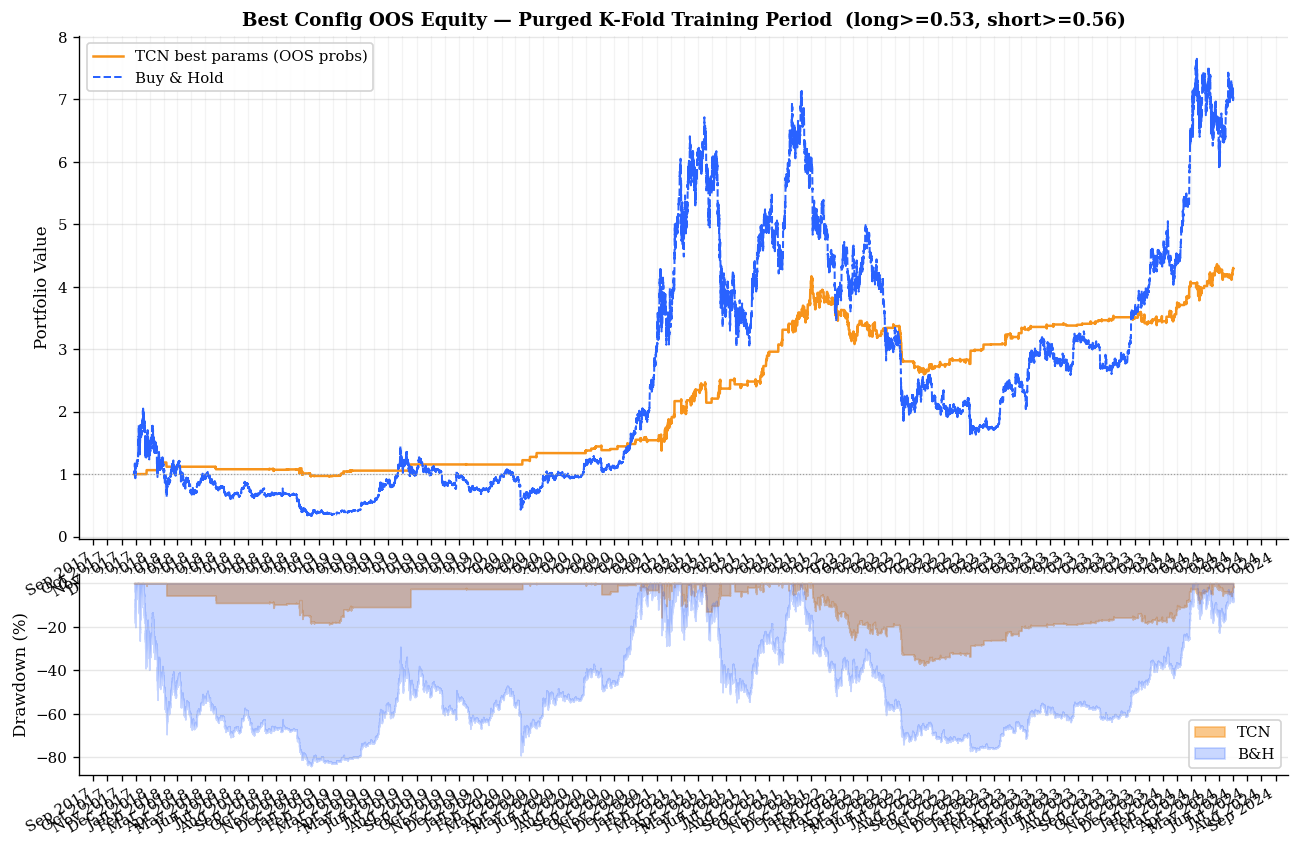

In [14]:
if results_df.empty:
    print('No results.')
else:
    best = results_df.sort_values(OPTIMISE_METRIC, ascending=False).iloc[0]
    best_p = {k: best[k] for k in keys}

    print('Best configuration (on OOS probs):')
    for k, v in best_p.items():
        print(f'  {k:<20} = {v}')
    print(f'  exit_threshold_long  = {max(0.28, best_p["long_threshold"]-0.10):.2f}  (derived)')
    print(f'  exit_threshold_short = {max(0.28, best_p["short_threshold"]-0.10):.2f}  (derived)')

    # Re-run best config to get equity curve + trade log
    lt  = best_p['long_threshold'];  st  = best_p['short_threshold']
    elt = max(0.28, lt - 0.10);      est = max(0.28, st - 0.10)
    atr = best_p['atr_multiplier'];  msl = best_p['min_sl']
    tp  = best_p['take_profit']
    mnh = best_p['min_hold'];        mxh = best_p['max_hold']
    cd  = best_p['cooldown']

    cash = 1.0; units = 0.0; in_pos = False; direction = None
    entry_px = 0.0; entry_cash = 0.0; dynamic_sl = 0.0
    hold_count = 0; cooldown = 0
    equity_oos = [1.0]; trade_log_oos = []

    for i, (ts, px, p_up, p_dn, atr_pct) in enumerate(
        zip(oos_index, oos_close, oos_up_valid, oos_down_valid, oos_atr)
    ):
        if cooldown > 0: cooldown -= 1

        if in_pos:
            hold_count += 1
            pnl    = (px - entry_px)/entry_px if direction == 'long' else (entry_px - px)/entry_px
            reason = None
            if   pnl <= -dynamic_sl:                                      reason = 'sl'
            elif pnl >= tp:                                                reason = 'tp'
            elif hold_count >= mxh:                                        reason = 'max_hold'
            elif hold_count >= mnh:
                if   direction == 'long'  and p_up < elt:                 reason = 'conf'
                elif direction == 'short' and p_dn < est:                 reason = 'conf'
            if reason:
                cash = units * px if direction == 'long' else entry_cash * (1 + pnl)
                units = 0.0
                trade_log_oos.append({
                    'entry_time': entry_ts, 'exit_time': ts, 'direction': direction,
                    'entry_px': entry_px, 'exit_px': px, 'pnl_pct': pnl,
                    'reason': reason, 'hold_h': hold_count
                })
                in_pos = False; hold_count = 0; cooldown = cd

        if not in_pos and cooldown == 0:
            sl = max(atr * atr_pct, msl)
            if p_up >= lt:
                units = cash / px; cash = 0.0; in_pos = True; direction = 'long'
                entry_px = px; entry_ts = ts; hold_count = 0; dynamic_sl = sl
            elif p_dn >= st and p_up < lt:
                entry_cash = cash; units = cash / px; in_pos = True; direction = 'short'
                entry_px = px; entry_ts = ts; hold_count = 0; dynamic_sl = sl

        if in_pos and direction == 'long':         equity_oos.append(units * px)
        elif in_pos and direction == 'short':      equity_oos.append(entry_cash * (1 + (entry_px - px) / entry_px))
        else:                                      equity_oos.append(cash)

    if in_pos:
        px  = oos_close[-1]
        pnl = (px - entry_px)/entry_px if direction == 'long' else (entry_px - px)/entry_px
        equity_oos[-1] = entry_cash * (1 + pnl) if direction == 'short' else units * px

    equity_oos_arr = np.array(equity_oos[1:])
    trades_oos_df  = pd.DataFrame(trade_log_oos)

    # Summary
    def _sharpe(eq, ann=24*365):
        r = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
        return float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(ann)) if len(r) > 1 else 0.0
    def _max_dd(eq):
        pk = np.maximum.accumulate(eq)
        return float(((eq - pk) / (pk + 1e-12)).min())

    print('\n' + '='*60)
    print('  BEST CONFIG on OOS TRAINING PROBS')
    print('='*60)
    print(f'  Trades (L/S)   : {len(trades_oos_df)}  '
          f'({(trades_oos_df["direction"]=="long").sum()} / '
          f'{(trades_oos_df["direction"]=="short").sum()})')
    if not trades_oos_df.empty:
        print(f'  Win rate       : {(trades_oos_df["pnl_pct"]>0).mean()*100:.1f}%')
    print(f'  Total return   : {(equity_oos_arr[-1]-1)*100:+.2f}%')
    print(f'  BH return      : {(bh_equity_oos[-1]-1)*100:+.2f}%')
    print(f'  Alpha          : {(equity_oos_arr[-1]-bh_equity_oos[-1])*100:+.2f}pp')
    print(f'  Sharpe (ann.)  : {_sharpe(equity_oos_arr):.3f}')
    print(f'  Max drawdown   : {_max_dd(equity_oos_arr)*100:.2f}%')
    print('='*60)

    # Plot OOS equity
    fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                             gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.10})
    ax = axes[0]
    ax.plot(oos_index, equity_oos_arr, color=ACCENT, lw=1.5,
            label='TCN best params (OOS probs)')
    ax.plot(oos_index, bh_equity_oos,  color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
    ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
    ax.set_ylabel('Portfolio Value'); ax.legend()
    ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)
    ax.set_title(f'Best Config OOS Equity — Purged K-Fold Training Period  '
                 f'(long>={best_p["long_threshold"]}, short>={best_p["short_threshold"]})',
                 fontweight='bold')

    ax = axes[1]
    pk_s = np.maximum.accumulate(equity_oos_arr)
    pk_b = np.maximum.accumulate(bh_equity_oos)
    ax.fill_between(oos_index, (equity_oos_arr - pk_s) / (pk_s + 1e-12) * 100, 0,
                    color=ACCENT, alpha=0.5, label='TCN')
    ax.fill_between(oos_index, (bh_equity_oos  - pk_b) / (pk_b + 1e-12) * 100, 0,
                    color=BLUE,   alpha=0.25, label='B&H')
    ax.set_ylabel('Drawdown (%)'); ax.legend(); ax.grid(axis='y', alpha=0.3)

    for ax in axes:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    fig.savefig(FIGURES_DIR / 'tcn_grid_oos_equity_vtrain.png')
    plt.show()

## 3. Final honest test evaluation

The best parameters were selected entirely on OOS training data above.
This cell applies them to the **test set exactly once** using the production model.

This is the only moment test data is used — there is no further parameter tuning after this cell.

In [15]:
# ── Load production model and QT ─────────────────────────────────────────────
qt_prod = pickle.loads((MODELS_DIR / 'tcn_qt.pkl').read_bytes())

prod_model = TCNMultiTask(len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
prod_model.load_state_dict(
    torch.load(MODELS_DIR / 'tcn_model.pt', map_location=DEVICE))
prod_model.eval()

# ── Build test sequences ─────────────────────────────────────────────────────
X_test_raw = qt_prod.transform(clean_test[ALL_INPUT_FEATS].values).astype(np.float32)
X_te = np.array(
    [X_test_raw[i - SEQ_LEN:i] for i in range(SEQ_LEN, len(X_test_raw))],
    dtype=np.float32
)

# ── Single forward pass ──────────────────────────────────────────────────────
all_logits = []
with torch.no_grad():
    for xb, in DataLoader(TensorDataset(torch.from_numpy(X_te)), batch_size=512):
        logits, _ = prod_model(xb.to(DEVICE))
        all_logits.append(logits.cpu())

logits_test = torch.cat(all_logits).numpy()
probs_test  = torch.softmax(torch.from_numpy(logits_test), dim=1).numpy()
test_probs_up   = probs_test[:, 1].astype(np.float32)
test_probs_down = probs_test[:, 0].astype(np.float32)

# Align test arrays
test_sig_index = clean_test.index[SEQ_LEN:SEQ_LEN + len(test_probs_up)]
test_close_arr = clean_test['close'].values[SEQ_LEN:SEQ_LEN + len(test_probs_up)].astype(np.float64)
test_atr_arr   = clean_test['atr_14_pct'].values[SEQ_LEN:SEQ_LEN + len(test_probs_up)].astype(np.float64)
test_bh_equity = test_close_arr / test_close_arr[0]

# Free production model
prod_model.cpu()
del prod_model
if DEVICE.type == 'mps': torch.mps.empty_cache()

print(f'Test sequences: {len(test_probs_up):,}')
print(f'Test period: {test_sig_index.min().date()} → {test_sig_index.max().date()}')

Test sequences: 13,212
Test period: 2024-11-11 → 2026-05-15


In [16]:
if results_df.empty:
    print('Grid search produced no valid results — cannot run final test evaluation.')
else:
    lt  = best_p['long_threshold'];  st  = best_p['short_threshold']
    elt = max(0.28, lt - 0.10);      est = max(0.28, st - 0.10)
    atr = best_p['atr_multiplier'];  msl = best_p['min_sl']
    tp  = best_p['take_profit']
    mnh = best_p['min_hold'];        mxh = best_p['max_hold']
    cd  = best_p['cooldown']

    cash = 1.0; units = 0.0; in_pos = False; direction = None
    entry_px = 0.0; entry_cash = 0.0; dynamic_sl = 0.0
    hold_count = 0; cooldown = 0
    equity_test = [1.0]; trade_log_test = []

    for i, (ts, px, p_up, p_dn, atr_pct) in enumerate(
        zip(test_sig_index, test_close_arr, test_probs_up, test_probs_down, test_atr_arr)
    ):
        if cooldown > 0: cooldown -= 1

        if in_pos:
            hold_count += 1
            pnl    = (px - entry_px)/entry_px if direction == 'long' else (entry_px - px)/entry_px
            reason = None
            if   pnl <= -dynamic_sl:                                      reason = 'sl'
            elif pnl >= tp:                                                reason = 'tp'
            elif hold_count >= mxh:                                        reason = 'max_hold'
            elif hold_count >= mnh:
                if   direction == 'long'  and p_up < elt:                 reason = 'conf'
                elif direction == 'short' and p_dn < est:                 reason = 'conf'
            if reason:
                cash = units * px if direction == 'long' else entry_cash * (1 + pnl)
                units = 0.0
                trade_log_test.append({
                    'entry_time': entry_ts, 'exit_time': ts, 'direction': direction,
                    'entry_px': entry_px, 'exit_px': px, 'pnl_pct': pnl,
                    'reason': reason, 'hold_h': hold_count
                })
                in_pos = False; hold_count = 0; cooldown = cd

        if not in_pos and cooldown == 0:
            sl = max(atr * atr_pct, msl)
            if p_up >= lt:
                units = cash / px; cash = 0.0; in_pos = True; direction = 'long'
                entry_px = px; entry_ts = ts; hold_count = 0; dynamic_sl = sl
            elif p_dn >= st and p_up < lt:
                entry_cash = cash; units = cash / px; in_pos = True; direction = 'short'
                entry_px = px; entry_ts = ts; hold_count = 0; dynamic_sl = sl

        if in_pos and direction == 'long':         equity_test.append(units * px)
        elif in_pos and direction == 'short':      equity_test.append(entry_cash * (1 + (entry_px - px)/entry_px))
        else:                                      equity_test.append(cash)

    if in_pos:
        px  = test_close_arr[-1]
        pnl = (px - entry_px)/entry_px if direction == 'long' else (entry_px - px)/entry_px
        equity_test[-1] = entry_cash * (1 + pnl) if direction == 'short' else units * px

    equity_test_arr = np.array(equity_test[1:])
    trades_test_df  = pd.DataFrame(trade_log_test)

    def _sharpe(eq, ann=24*365):
        r = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
        return float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(ann)) if len(r) > 1 else 0.0
    def _max_dd(eq):
        pk = np.maximum.accumulate(eq)
        return float(((eq - pk) / (pk + 1e-12)).min())

    print('='*62)
    print('  FINAL HONEST TEST EVALUATION  (params from OOS K-Fold)')
    print('='*62)
    print(f'  Test period: {test_sig_index.min().date()} → {test_sig_index.max().date()}')
    print(f'  Parameters used:')
    for k, v in best_p.items():
        print(f'    {k:<20} = {v}')
    print()
    if not trades_test_df.empty:
        long_t  = trades_test_df[trades_test_df['direction'] == 'long']
        short_t = trades_test_df[trades_test_df['direction'] == 'short']
        print(f'  Total trades   : {len(trades_test_df)}  (Long: {len(long_t)}, Short: {len(short_t)})')
        print(f'  Win rate       : {(trades_test_df["pnl_pct"]>0).mean()*100:.1f}%')
        print('  Exit reasons:')
        for reason, grp in trades_test_df.groupby('reason'):
            wr = (grp['pnl_pct'] > 0).mean() * 100
            print(f'    {reason:<12}  n={len(grp):>3}  win={wr:.1f}%  avg={grp["pnl_pct"].mean()*100:+.2f}%')
    else:
        print('  No trades generated on test set.')
    print()
    print(f'  Total return   : {(equity_test_arr[-1]-1)*100:+.2f}%')
    print(f'  BH return      : {(test_bh_equity[-1]-1)*100:+.2f}%')
    print(f'  Alpha          : {(equity_test_arr[-1]-test_bh_equity[-1])*100:+.2f}pp')
    print(f'  Sharpe (ann.)  : {_sharpe(equity_test_arr):.3f}')
    print(f'  Max drawdown   : {_max_dd(equity_test_arr)*100:.2f}%')
    print('='*62)

  FINAL HONEST TEST EVALUATION  (params from OOS K-Fold)
  Test period: 2024-11-11 → 2026-05-15
  Parameters used:
    long_threshold       = 0.53
    short_threshold      = 0.56
    atr_multiplier       = 1.5
    min_sl               = 0.02
    take_profit          = 0.045
    min_hold             = 8.0
    max_hold             = 24.0
    cooldown             = 3.0

  Total trades   : 75  (Long: 72, Short: 3)
  Win rate       : 60.0%
  Exit reasons:
    conf          n= 51  win=80.4%  avg=+0.89%
    max_hold      n=  3  win=0.0%  avg=-1.10%
    sl            n= 17  win=0.0%  avg=-3.04%
    tp            n=  4  win=100.0%  avg=+5.70%

  Total return   : +11.68%
  BH return      : -1.02%
  Alpha          : +12.70pp
  Sharpe (ann.)  : 0.446
  Max drawdown   : -19.08%


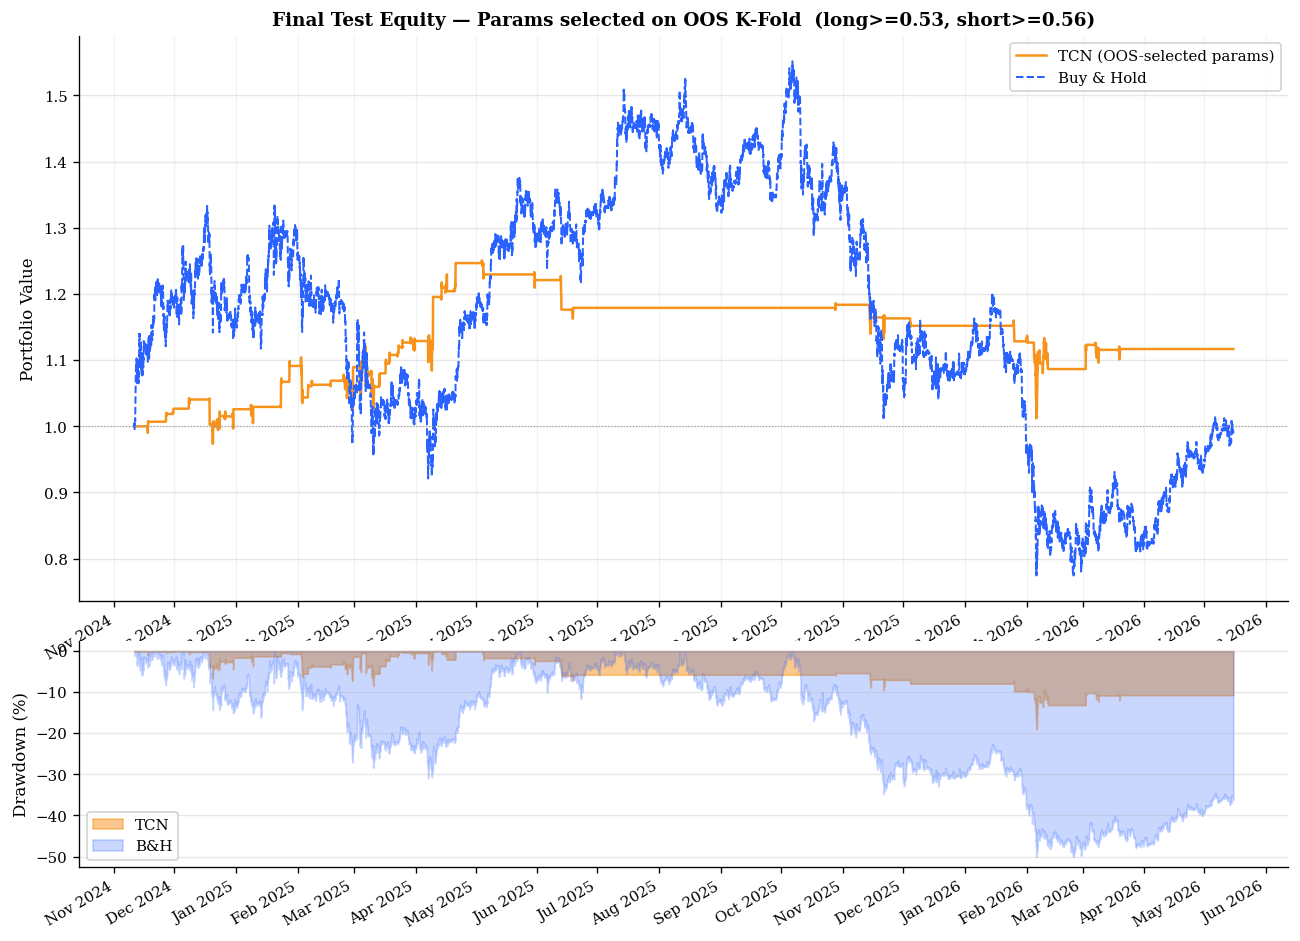

In [17]:
if not results_df.empty and 'equity_test_arr' in dir():
    fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                             gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.10})

    ax = axes[0]
    ax.plot(test_sig_index, equity_test_arr, color=ACCENT, lw=1.5,
            label='TCN (OOS-selected params)')
    ax.plot(test_sig_index, test_bh_equity,  color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
    ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
    ax.set_ylabel('Portfolio Value'); ax.legend()
    ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)
    ax.set_title(
        f'Final Test Equity — Params selected on OOS K-Fold  '
        f'(long>={best_p["long_threshold"]}, short>={best_p["short_threshold"]})',
        fontweight='bold')

    ax = axes[1]
    pk_s = np.maximum.accumulate(equity_test_arr)
    pk_b = np.maximum.accumulate(test_bh_equity)
    ax.fill_between(test_sig_index, (equity_test_arr - pk_s)/(pk_s + 1e-12)*100, 0,
                    color=ACCENT, alpha=0.5, label='TCN')
    ax.fill_between(test_sig_index, (test_bh_equity  - pk_b)/(pk_b + 1e-12)*100, 0,
                    color=BLUE,   alpha=0.25, label='B&H')
    ax.set_ylabel('Drawdown (%)'); ax.legend(); ax.grid(axis='y', alpha=0.3)

    for ax in axes:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    fig.savefig(FIGURES_DIR / 'tcn_grid_test_equity_vtrain.png')
    plt.show()

In [18]:
if not results_df.empty:
    # Save full grid results
    out_csv = MODELS_DIR / 'tcn_grid_results_vtrain.csv'
    results_df.sort_values(OPTIMISE_METRIC, ascending=False).to_csv(out_csv, index=False)
    print(f'Saved: {out_csv}')

    # Save best params JSON
    test_return = float(equity_test_arr[-1] - 1) if 'equity_test_arr' in dir() else None
    test_sharpe = _sharpe(equity_test_arr) if 'equity_test_arr' in dir() else None
    test_maxdd  = _max_dd(equity_test_arr)  if 'equity_test_arr' in dir() else None
    test_ntrades = len(trades_test_df) if 'trades_test_df' in dir() else None

    best_params_out = {
        **{k: (int(v) if isinstance(v, (np.integer,)) else
               float(v) if isinstance(v, (np.floating,)) else v)
           for k, v in best_p.items()},
        'exit_threshold_long':  round(max(0.28, best_p['long_threshold']  - 0.10), 2),
        'exit_threshold_short': round(max(0.28, best_p['short_threshold'] - 0.10), 2),
        'optimised_metric':     OPTIMISE_METRIC,
        'selection_method':     'purged_kfold_oos',
        'K':                    K,
        'embargo':              EMBARGO,
        # OOS metrics (on which params were selected)
        'oos_sharpe':        round(float(best['sharpe']),        4),
        'oos_total_return':  round(float(best['total_return']),  4),
        'oos_max_dd':        round(float(best['max_dd']),        4),
        'oos_n_trades':      int(best['n_trades']),
        # Final test metrics
        'test_sharpe':       round(test_sharpe, 4) if test_sharpe is not None else None,
        'test_total_return': round(test_return, 4) if test_return  is not None else None,
        'test_max_dd':       round(test_maxdd,  4) if test_maxdd   is not None else None,
        'test_n_trades':     test_ntrades,
    }

    out_json = MODELS_DIR / 'tcn_best_trading_params_vtrain.json'
    with open(out_json, 'w') as f:
        json.dump(best_params_out, f, indent=2)
    print(f'Saved: {out_json}')
    print()
    print(json.dumps(best_params_out, indent=2))
else:
    print('No results to save.')

Saved: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/tcn_grid_results_vtrain.csv
Saved: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/tcn_best_trading_params_vtrain.json

{
  "long_threshold": 0.53,
  "short_threshold": 0.56,
  "atr_multiplier": 1.5,
  "min_sl": 0.02,
  "take_profit": 0.045,
  "min_hold": 8.0,
  "max_hold": 24.0,
  "cooldown": 3.0,
  "exit_threshold_long": 0.43,
  "exit_threshold_short": 0.46,
  "optimised_metric": "sharpe",
  "selection_method": "purged_kfold_oos",
  "K": 5,
  "embargo": 168,
  "oos_sharpe": 1.1503,
  "oos_total_return": 3.2979,
  "oos_max_dd": -0.377,
  "oos_n_trades": 388,
  "test_sharpe": 0.4456,
  "test_total_return": 0.1168,
  "test_max_dd": -0.1908,
  "test_n_trades": 75
}
